# Value at Risk (VaR) & Expected Shortfall



In [1]:
!pip -q install yfinance plotly

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np,pandas as pd,yfinance as yf
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import norm
plt.style.use("ggplot")

In [3]:
tickers=['AAPL','MSFT','NVDA','AMZN','GOOGL']
weights=np.array([0.2]*5)
prices=yf.download(tickers,start='2018-01-01',progress=False,auto_adjust=True)['Close'].ffill().dropna()
returns=prices.pct_change().dropna()
portfolio_returns=(returns*weights).sum(axis=1)

In [4]:
def historical_var(r,a=0.95): return -np.percentile(r,(1-a)*100)
def parametric_var(r,a=0.95):
    return -(r.mean()+norm.ppf(1-a)*r.std())
def monte_carlo_var(r,a=0.95,n=100000):
    sims=np.random.normal(r.mean(),r.std(),n)
    return -np.percentile(sims,(1-a)*100)
def expected_shortfall(r,a=0.95):
    v=np.percentile(r,(1-a)*100)
    return -r[r<=v].mean()
metrics={
'Historical VaR':historical_var(portfolio_returns),
'Parametric VaR':parametric_var(portfolio_returns),
'Monte Carlo VaR':monte_carlo_var(portfolio_returns),
'Expected Shortfall':expected_shortfall(portfolio_returns)}
pd.DataFrame(metrics,index=['Value']).T

,Value
Historical VaR,0.029678
Parametric VaR,0.028825
Monte Carlo VaR,0.028539
Expected Shortfall,0.042116


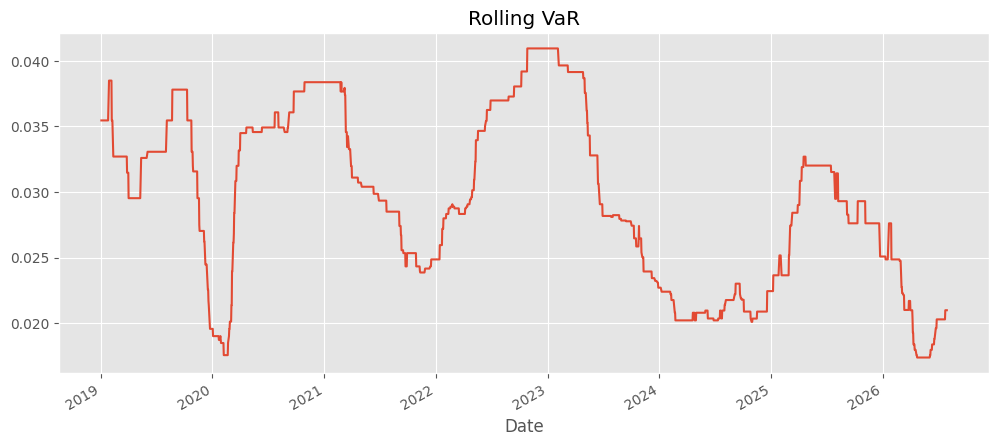

In [5]:
cum=(1+portfolio_returns).cumprod()
go.Figure(go.Scatter(x=cum.index,y=cum)).update_layout(title='Portfolio Growth').show()
fig=px.histogram(portfolio_returns,nbins=60,title='Return Distribution')
fig.add_vline(x=-metrics['Historical VaR'],line_color='red')
fig.show()
rolling=portfolio_returns.rolling(252).apply(lambda x: historical_var(pd.Series(x)))
rolling.plot(figsize=(12,5),title='Rolling VaR')
plt.show()